# 02 — Model-Independent P(k) MCMC Sampling: DESI 6-Sky Mock (GPU)

Runs full posterior inference on the model-independent parametrisation and compares
four information pathways:

- **(a) P(k)-only MCMC** — sample (ω_cdm, ln10As, h) via Gaussian likelihood built from P(k) chain
- **(b) Growth-only MCMC** — same via growth chain
- **(c) Combined** — joint P(k) + growth Gaussian likelihood
- **(d) Direct** — standard EFT MCMC on (ω_cdm, ln10As, h, EFT)

**Step 1:** run `scripts/generate_fake_data.py`  
**Step 2 (optional):** run `01_fisher_information.ipynb` for comparison Fisher contours  
**Step 3:** run this notebook on a GPU node

GPU tip: Run `sbatch` with `#SBATCH --gpus=1` and set `JAX_PLATFORMS=gpu` below.

In [1]:
import os
# Set GPU mode before importing JAX.
# Switch to 'cpu' for debugging or if no GPU is available.
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["CUDA_DEVICE_ORDER"]         = "PCI_BUS_ID"

import numpy as np
import matplotlib.pyplot as plt
import yaml, emcee
import jax
import jax.numpy as jnp
import jax.scipy as jsp
from scipy.interpolate import interp1d
from getdist import MCSamples, plots

jax.config.update("jax_enable_x64", True)
print(f"JAX devices: {jax.devices()}")

from pybird import config as pybird_config
pybird_config.set_jax_enabled(True)
from pybird.module import *
from pybird.likelihood import Likelihood
from pybird.fake import Fake
from pybird.symbolic import Symbolic
from pybird.symbolic_pofk_linear import plin_emulated

from utils import DESI_Y6, to_Mpc, to_Mpc_jax, to_Mpc_per_h_jax

from cosmopower_jax.cosmopower_jax import CosmoPowerJAX as CPJ


plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14

PROJECT_ROOT = os.path.abspath('..')
OUTPUT_DIR   = os.path.join(PROJECT_ROOT, 'output')
os.makedirs(OUTPUT_DIR, exist_ok=True)

JAX devices: [CudaDevice(id=0)]
jax: on


## 1. Setup (Same as Notebook 01)

In [2]:
cosmo_fid = {
    'omega_b':      0.02235,
    'omega_cdm':    0.120,
    'h':            0.675,
    'ln10^{10}A_s': 3.044,
    'n_s':          0.965,
}
h_fid  = cosmo_fid['h']
z_ref  = 5.0

s            = DESI_Y6
num_skies    = s['n_sky']
zeff_list    = s['zeff']
zeff_unique  = sorted(set(zeff_list))
n_z_unique   = len(zeff_unique)
sky_to_z_idx = [zeff_unique.index(z) for z in zeff_list]

M_sym = Symbolic()
M_sym.set(cosmo_fid)
kk_tmp = np.logspace(-4, np.log10(0.7), 200)
M_sym.compute(kk_tmp, 0.5)
Omega0_m = M_sym.c['Omega_m']

print(f"DESI Y6: {num_skies} skies, {n_z_unique} unique z_eff = {zeff_unique}")
print(f"JAX device: {jax.devices()[0]}")

DESI Y6: 7 skies, 6 unique z_eff = [0.295, 0.51, 0.706, 0.93, 1.317, 1.491]
JAX device: cuda:0


In [3]:
cpj_pklin = CPJ(probe='mpk_lin')
cpj_k_modes = jnp.array(cpj_pklin.modes)  # k in 1/Mpc (CPJ native units - NOT h/Mpc!)

def pklin_cpj(k_mpc, omega_b, omega_cdm, h, lnAs, n_s, z):
    """
    JAX-differentiable P_lin using CosmoPower-JAX.
    
    IMPORTANT: CPJ uses pure Mpc units internally:
      - k modes are in 1/Mpc (NOT h/Mpc)
      - P(k) output is in Mpc³ (NOT (Mpc/h)³)
    
    This function outputs pk in Mpc^3 
    
    Args:
        k_h: wavenumbers in 1/Mpc
        omega_b, omega_cdm: physical densities
        h, lnAs, n_s: cosmological params
        z: redshift (scalar)
    
    Returns:
        P_lin in (Mpc/h)³ at requested k values (PyBird convention)
    """
    input_dict = {
        'omega_b': jnp.atleast_1d(omega_b),
        'omega_cdm': jnp.atleast_1d(omega_cdm),
        'h': jnp.atleast_1d(h),
        'ln10^{10}A_s': jnp.atleast_1d(lnAs),
        'n_s': jnp.atleast_1d(n_s),
        'z': jnp.atleast_1d(z)
    }
    pk_cpj_mpc = cpj_pklin.predict(input_dict)  # P(k) in Mpc³ at cpj_k_modes (1/Mpc)
    
    
    # Interpolate in log-space for numerical stability onto the grid of k_mpc
    log_pk_out = jnp.interp(jnp.log(k_mpc), jnp.log(cpj_k_modes), jnp.log(pk_cpj_mpc))
    pk_mpc = jnp.exp(log_pk_out)  # P(k) in Mpc³
    return pk_mpc

In [4]:
# Use template config from existing DESI Y6 setup
rootdir = '/cluster/work/refregier/alexree/pybird_model_independent'
fakedir = os.path.join(rootdir, 'data', 'fake')
fakeconfigdir = os.path.join(fakedir, 'likelihood_config')
template_configfile = os.path.join(fakeconfigdir, 'fake_fast_pk_desi_y6.yaml')

# Output paths for this analysis
output_path = '/cluster/work/refregier/alexree/pybird_emu/notebooks/model_independent_analysis/'
fake_data_name = 'fake_desi_y6_fisher'
fake_config_name = 'fake_desi_y6_fisher_config'

print("Generating fake DESI Y6 data...")
print(f"Template config: {template_configfile}")

s = DESI_Y6
F = Fake(
    s['n_sky'], s['zmin'], s['zmax'], s['zeff'], s['Veff'], s['degsq'], s['P0'], 
    cosmo_fid, 
    likelihood_config_template_file=template_configfile, 
    boltzmann='CPJ',
    Omega_m_fid=Omega0_m, 
    kmin=0.01, kmax=0.2, dk=0.01, 
    nbar_prior=s['nbar_prior'],
    fake_data_filename=fake_data_name, 
    path_to_data=output_path, 
    fake_likelihood_config_filename=fake_config_name, 
    path_to_config=output_path
)

# Generate fake data
F.set()

# Get fiducial EFT params from Fake class
fiducial_nuisance = F.fiducial_nuisance[0]  # Same for all skies
print(f"\nFiducial EFT: {fiducial_nuisance}")
print("Fake DESI Y6 data generated!")

Generating fake DESI Y6 data...
Template config: /cluster/work/refregier/alexree/pybird_model_independent/data/fake/likelihood_config/fake_fast_pk_desi_y6.yaml
jax: on
No fiducial EFT parameters specified, using default ones
bsky[i] {'b1': 1.9542, 'b2': 0.4173, 'b4': 0.4173, 'b3': -0.3686, 'cct': 0.1843, 'cr1': -0.8477, 'cr2': -0.8141, 'ce0': 0.0, 'ce1': 0.0, 'ce2': -1.6279, 'cr4': 0.0, 'cr6': 0.0}
bsky[i] {'b1': 1.9542, 'b2': 0.4173, 'b4': 0.4173, 'b3': -0.3686, 'cct': 0.1843, 'cr1': -0.8477, 'cr2': -0.8141, 'ce0': 0.0, 'ce1': 0.0, 'ce2': -1.6279, 'cr4': 0.0, 'cr6': 0.0}
bsky[i] {'b1': 1.9542, 'b2': 0.4173, 'b4': 0.4173, 'b3': -0.3686, 'cct': 0.1843, 'cr1': -0.8477, 'cr2': -0.8141, 'ce0': 0.0, 'ce1': 0.0, 'ce2': -1.6279, 'cr4': 0.0, 'cr6': 0.0}
bsky[i] {'b1': 1.9542, 'b2': 0.4173, 'b4': 0.4173, 'b3': -0.3686, 'cct': 0.1843, 'cr1': -0.8477, 'cr2': -0.8141, 'ce0': 0.0, 'ce1': 0.0, 'ce2': -1.6279, 'cr4': 0.0, 'cr6': 0.0}
bsky[i] {'b1': 1.9542, 'b2': 0.4173, 'b4': 0.4173, 'b3': -0.3686, '

In [5]:
# Load the generated fake likelihood config
fake_config_path = os.path.join(output_path, f'{fake_config_name}.yaml')
lkl_config = yaml.full_load(open(fake_config_path))

lkl_config['get_maxlkl'] = True 
print(f"Set drop_logdet = True to ensure chi2 = 0 at fiducial")

# Initialize likelihood with fake data
L_jax = Likelihood(lkl_config)

# Test that fiducial gives log-likelihood = 0 (chi2 = 0)
eft_fid_flat = np.array([fiducial_nuisance['b1'], fiducial_nuisance['b2'], fiducial_nuisance['b4']] * num_skies)
eft_names_flat = ['b1', 'b2', 'b4'] * num_skies

# Create a k-array compatible with the fake data (k: 0.001 to 0.35)
# Use a simple logspace that covers the needed range without being too large
kk_lkl = jnp.logspace(np.log10(0.0001), np.log10(1), 500)

# Build cosmo_dict for each sky at fiducial using Symbolic
cosmo_dict_fid = []
for i_sky in range(num_skies):
    z = zeff_list[i_sky]
    M_sym.compute(kk_lkl, z)
    pklin_mpc = pklin_cpj(
    jnp.array(kk_lkl*cosmo_fid["h"]), 
    cosmo_fid['omega_b'], 
    cosmo_fid['omega_cdm'],
    cosmo_fid['h'],
    cosmo_fid['ln10^{10}A_s'],
    cosmo_fid['n_s'],
    z
    )
    pklin_h = to_Mpc_per_h_jax(pklin_mpc, jnp.array(kk_lkl*cosmo_fid["h"]), cosmo_fid["h"], kk_lkl)
    cosmo_dict_fid.append({
        "H": float(M_sym.H),     # H(z)/H_0 - convert to Python float
        "DA": float(M_sym.DA),   # D_A(z)*H_0 - convert to Python float
        "pk_lin": pklin_h,
        "kk": kk_lkl,
        "f": float(M_sym.f)      # f(z) - convert to Python float
    })

lkl_at_fid = L_jax.loglkl(eft_fid_flat, eft_names_flat, 
                          need_cosmo_update=True, cosmo_dict=cosmo_dict_fid,
                          cosmo_module=None, cosmo_engine=None)
chi2_at_fid = -2 * float(lkl_at_fid)

print(f"\n{'='*50}")
print("SANITY CHECK: Likelihood at fiducial cosmology")
print(f"{'='*50}")
print(f"Log-likelihood at fiducial: {float(lkl_at_fid):.6f}")
print(f"Chi-squared at fiducial:    {chi2_at_fid:.6f}")
print(f"Expected (for theory data): 0.0")
print(f"{'='*50}")

if np.abs(chi2_at_fid) < 0.01:
    print("✓ SUCCESS: Chi-squared is essentially zero!")
else:
    print("⚠ WARNING: Chi-squared is not zero - check the setup!")


Set drop_logdet = True to ensure chi2 = 0 at fiducial
reading data file: /cluster/work/refregier/alexree/pybird_emu/notebooks/model_independent_analysis/fake_desi_y6_fisher.h5
-----------------------
sky: sky_1
output: bPk
multipole: 3
min bound (per multipole): [0.01, 0.01, 0.01]
max bound (per multipole): [0.2, 0.2, 0.2]
coordinate (AP) distortion: on
-----------------------
-----------------------
sky: sky_2
output: bPk
multipole: 3
min bound (per multipole): [0.01, 0.01, 0.01]
max bound (per multipole): [0.2, 0.2, 0.2]
coordinate (AP) distortion: on
-----------------------
-----------------------
sky: sky_3
output: bPk
multipole: 3
min bound (per multipole): [0.01, 0.01, 0.01]
max bound (per multipole): [0.2, 0.2, 0.2]
coordinate (AP) distortion: on
-----------------------
-----------------------
sky: sky_4
output: bPk
multipole: 3
min bound (per multipole): [0.01, 0.01, 0.01]
max bound (per multipole): [0.2, 0.2, 0.2]
coordinate (AP) distortion: on
-----------------------
--------


P_lin at z_ref=5.0 (computed with CosmoPower-JAX):
  Number of knots: 38 (4 low-k buffer + 20 main)
  k range: [0.0050, 0.350] h/Mpc
  Main range: [0.03, 0.35] h/Mpc (where information lives)
  P(k) range: [9.81e+01, 3.63e+03] Mpc³
  Note: Stored in Mpc³ (1/Mpc units), converted to (Mpc/h)³ for PyBird
  Using z_ref=5.0 for better h-independence than z_ref=3


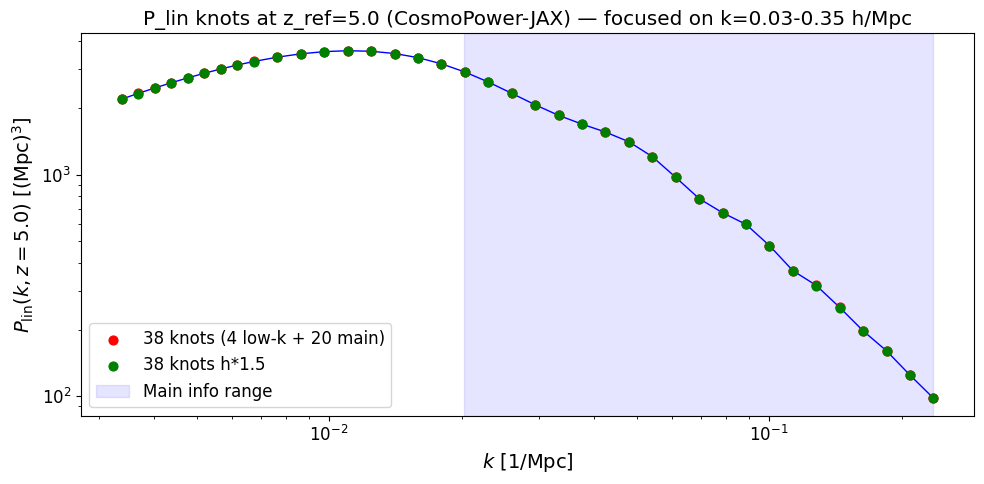

In [6]:
# =============================================================================
# IMPORTANT: Use CosmoPower-JAX to compute fiducial P(k) at z_ref=5
# This provides accurate P(k) at higher redshift than Symbolic (limited to z=3)
# =============================================================================
from pybird.symbolic import D

# =============================================================================
# Knots for P_lin parametrization
# Focus on k range where P(k) carries information: ~0.03-0.35 h/Mpc
# A few knots on the low-k side for interpolation stability, but most in 0.03-0.35
# =============================================================================
# Low-k buffer knots (sparse, just for interpolation boundary)
k_low = np.logspace(np.log10(0.005), np.log10(0.01), 8, endpoint=False)  # 4 knots below 0.03
# Main information-carrying range
k_main = np.logspace(np.log10(0.01), np.log10(0.35), 30)  # 20 knots in 0.03-0.35

knots_h = np.concatenate([k_low, k_main])  # total ~24 knots
n_knots = len(knots_h)
knots_h_jax = jnp.array(knots_h)

# Convert knots to 1/Mpc for Mpc³ storage: knots (1/Mpc) = knots_h (h/Mpc) * h
knots_mpc = knots_h * cosmo_fid['h']  # k in 1/Mpc
# these are the knots at which we will learn the pk 

knots_mpc_jax = jnp.array(knots_mpc)

# =============================================================================
# Fiducial P(k) at knots using CosmoPower-JAX
# Store in Mpc³ (units: 1/Mpc) at z_ref for h-independence
# At z_ref=5, P(k) in Mpc³ should have minimal h-dependence
# =============================================================================

# Compute fiducial P(k) at z_ref using CPJ
pk_at_knots = pklin_cpj(
    knots_mpc_jax,
    cosmo_fid['omega_b'],
    cosmo_fid['omega_cdm'],
    cosmo_fid['h'],
    cosmo_fid['ln10^{10}A_s'],
    cosmo_fid['n_s'],
    z_ref
)


pk_at_knots2 = pklin_cpj(
    knots_mpc_jax,
    cosmo_fid['omega_b'],
    cosmo_fid['omega_cdm'],
    cosmo_fid['h']*1.1,
    cosmo_fid['ln10^{10}A_s'],
    cosmo_fid['n_s'],
    z_ref
)

pk_at_knots_jax = jnp.array(pk_at_knots)

print(f"\nP_lin at z_ref={z_ref} (computed with CosmoPower-JAX):")
print(f"  Number of knots: {n_knots} (4 low-k buffer + 20 main)")
print(f"  k range: [{knots_h.min():.4f}, {knots_h.max():.3f}] h/Mpc")
print(f"  Main range: [0.03, 0.35] h/Mpc (where information lives)")
print(f"  P(k) range: [{float(pk_at_knots.min()):.2e}, {float(pk_at_knots.max()):.2e}] Mpc³")
print(f"  Note: Stored in Mpc³ (1/Mpc units), converted to (Mpc/h)³ for PyBird")
print(f"  Using z_ref={z_ref} for better h-independence than z_ref=3")

# Visualize knot positions
fig, ax = plt.subplots(figsize=(10, 5))
ax.loglog(np.array(knots_mpc), np.array(pk_at_knots), 'b-', lw=1)
ax.scatter(np.array(knots_mpc), np.array(pk_at_knots), c='red', s=40, zorder=5, label=f'{n_knots} knots (4 low-k + 20 main)')
ax.scatter(np.array(knots_mpc), np.array(pk_at_knots2), c='green', s=40, zorder=5, label=f'{n_knots} knots h*1.5')

# Mark the main information range
k_main_mpc = np.array([0.03, 0.35]) * cosmo_fid['h']
ax.axvspan(k_main_mpc[0], k_main_mpc[1], alpha=0.1, color='blue', label='Main info range')

ax.set_xlabel(r'$k$ [1/Mpc]')
ax.set_ylabel(r'$P_{\rm lin}(k, z=' + str(z_ref) + r')$ [(Mpc)$^3$]')
ax.legend()
ax.set_title(f'P_lin knots at z_ref={z_ref} (CosmoPower-JAX) — focused on k=0.03-0.35 h/Mpc')
plt.tight_layout()

In [7]:
# EFT parameters for 7 DESI skies - use the fiducial values from fake data generation
eft_free_names = ["b1", "b2", "b4"]  # Free EFT parameters

# Use the same EFT values as fiducial_nuisance (same for all skies)
eft_init = np.array([fiducial_nuisance[key] for _ in range(num_skies) for key in eft_free_names])
eft_param_names = [f"{key}_{i+1}" for i in range(num_skies) for key in eft_free_names]

print(f"DESI Y6 configuration: {num_skies} skies")
print(f"Free EFT parameters per sky: {eft_free_names}")
print(f"Total free EFT parameters: {len(eft_init)}")
print(f"EFT init values (first 9): {eft_init[:9]} ...")

# NOTE: We use L_jax from cell 6 (fake data likelihood) - DO NOT reload here!

DESI Y6 configuration: 7 skies
Free EFT parameters per sky: ['b1', 'b2', 'b4']
Total free EFT parameters: 21
EFT init values (first 9): [1.9542 0.4173 0.4173 1.9542 0.4173 0.4173 1.9542 0.4173 0.4173] ...


In [11]:
# Compute fiducial cosmology with Symbolic for growth factors (still needed)
from pybird.symbolic import Symbolic
M_sym = Symbolic()
M_sym.set(cosmo_fid)

# Compute at z_ref for growth factor reference
M_sym.compute(knots_h, z_ref)
D_ref = M_sym.D  # Growth factor at z_ref
Omega0_m = M_sym.c['Omega_m']

print(f"\nFiducial cosmology: omega_cdm = {cosmo_fid['omega_cdm']}, h = {cosmo_fid['h']}")
print(f"Omega_m = {Omega0_m:.4f}")
print(f"D(z_ref={z_ref}) = {D_ref:.6f}")

# Compute fiducial growth at each unique DESI redshift
D1_fid = {}    # Growth factor D(z)
f_fid = {}     # Growth rate f(z)
H_fid = {}     # H(z)/H_0
DA_fid = {}    # D_A(z)*H_0

print(f"\nGrowth factors at each unique redshift (with h_fid scaling):")
print("-"*70)
print(f"{'z':>6} {'f':>8} {'H/H0':>8} {'DA*H0':>8} {'D':>8} | {'(H/H0)*h_fid':>12} {'(DA*H0)*h_fid':>14}")
print("-"*70)

for z in zeff_unique:
    M_sym.compute(knots_h, z)
    D1_fid[z] = M_sym.D
    f_fid[z] = M_sym.f
    H_fid[z] = M_sym.H  # Already H(z)/H_0
    DA_fid[z] = M_sym.DA  # Already D_A(z)*H_0
    
    H_scaled = H_fid[z] * h_fid
    DA_scaled = DA_fid[z] * h_fid
    print(f"{z:>6.3f} {f_fid[z]:>8.4f} {H_fid[z]:>8.4f} {DA_fid[z]:>8.4f} {D1_fid[z]:>8.4f} | {H_scaled:>12.4f} {DA_scaled:>14.4f}")
    


growth_fid_list = []
growth_names = []

# knots_mpc is already defined in cell 8 (k in 1/Mpc)
# Use it consistently - do NOT redefine here!
print(f"Number of knots: {n_knots}")
print(f"k range: [{knots_h.min():.4f}, {knots_h.max():.3f}] h/Mpc")
print(f"k range (1/Mpc): [{knots_mpc.min():.4f}, {knots_mpc.max():.3f}] 1/Mpc")

print("="*70)
print("NEW PARAMETRIZATION: Growth = [f, H/H0, DA*H0, D_ratios, h_conv]")
print("  - f, H, DA: depend on Omega_m = omega_m/h² (physics)")
print("  - h_conv: direct parameter for unit conversion (identity Jacobian)")
print("="*70)


# f, H/H0, DA*H0 at each unique redshift (NOT scaled by h)
for z in zeff_unique:
    growth_fid_list.extend([f_fid[z], H_fid[z], DA_fid[z]])
    growth_names.extend([f'f(z={z:.2f})', f'H/H0(z={z:.2f})', f'DA*H0(z={z:.2f})'])
    print(f"z={z:.3f}: f={f_fid[z]:.4f}, H/H0={H_fid[z]:.4f}, DA*H0={DA_fid[z]:.4f}")

# Growth ratios D(z)/D(z_ref) for ALL z (z_ref=10, where P(k) is stored)
print("-"*70)
print(f"D ratios relative to z_ref={z_ref}:")
for z in zeff_unique:
    ratio = D1_fid[z] / D_ref
    growth_fid_list.append(ratio)
    growth_names.append(f'D(z={z:.2f})/D(z_ref)')
    print(f"D(z={z:.3f})/D(z_ref={z_ref}) = {ratio:.4f}")

# h_conv: the unit conversion parameter (equals h at fiducial)
h_conv_fid = cosmo_fid['h']
growth_fid_list.append(h_conv_fid)
growth_names.append('h_conv')
print("-"*70)
print(f"h_conv (unit conversion): {h_conv_fid:.4f}")

growth_fid = np.array(growth_fid_list)
n_growth = len(growth_fid)

# =============================================================================
# Build full fiducial parameter vector
# =============================================================================
pk_amps_fid = np.ones(n_knots)  # Relative amplitudes = 1 at fiducial
params_fid = np.concatenate([eft_init, pk_amps_fid, growth_fid])

print(f"\n{'='*70}")
print(f"Total parameters: {len(params_fid)}")
print(f"  - EFT: {len(eft_init)} (3 per sky x {num_skies} skies)")
print(f"  - P(k) knots: {n_knots} (amplitudes)")
print(f"  - Growth: {n_growth} ({n_z_unique} z x 3 params + {n_z_unique} D-ratios + 1 h_conv)")


Fiducial cosmology: omega_cdm = 0.12, h = 0.675
Omega_m = 0.3124
D(z_ref=5.0) = 0.211678

Growth factors at each unique redshift (with h_fid scaling):
----------------------------------------------------------------------
     z        f     H/H0    DA*H0        D | (H/H0)*h_fid  (DA*H0)*h_fid
----------------------------------------------------------------------
 0.295   0.6804   1.1688   0.2115   0.8557 |       0.7889         0.1427
 0.510   0.7624   1.3279   0.2958   0.7659 |       0.8963         0.1997
 0.706   0.8178   1.4963   0.3434   0.6954 |       1.0100         0.2318
 0.930   0.8638   1.7128   0.3761   0.6269 |       1.1561         0.2538
 1.317   0.9144   2.1386   0.4006   0.5327 |       1.4436         0.2704
 1.491   0.9294   2.3488   0.4038   0.4983 |       1.5854         0.2725
Number of knots: 38
k range: [0.0050, 0.350] h/Mpc
k range (1/Mpc): [0.0034, 0.236] 1/Mpc
NEW PARAMETRIZATION: Growth = [f, H/H0, DA*H0, D_ratios, h_conv]
  - f, H, DA: depend on Omega_m = omega_

## 2. Model-Independent Likelihood (GPU-Accelerated)

In [12]:
# Map each sky to its unique redshift index
sky_to_z_idx = [zeff_unique.index(z) for z in zeff_list]
print(f"Sky to unique z index mapping: {sky_to_z_idx}")

# Growth parameters layout:
# - For each unique z: [f, H/H0, DA*H0] (NOT scaled by h)
# - Then D-ratios: D(z)/D(z_ref) for each unique z
# - Finally: h_conv (unit conversion parameter)
n_growth_per_z = 3  # f, H/H0, DA*H0
n_growth_ratios = n_z_unique  # D(z)/D(z_ref=10) for ALL z
n_growth = n_z_unique * n_growth_per_z + n_growth_ratios + 1  # +1 for h_conv

print(f"Growth parameters: {n_z_unique} x 3 (f, H/H0, DA*H0) + {n_growth_ratios} D-ratios + 1 h_conv = {n_growth}")

def model_independent_loglkl(params):
    """
    Model-independent log-likelihood for DESI Y6.
    
    PARAMETRIZATION:
    - EFT parameters (21 = 3 per sky x 7 skies)
    - P(k) amplitudes at knots (relative to fiducial at z_ref=10)
      * Stored in Mpc³ (1/Mpc units) for h-independence
      * Converted to (Mpc/h)³ using h_conv when feeding to PyBird
    - Growth parameters: [f_z, H/H0_z, DA*H0_z for each z, D_ratios, h_conv]
      * h_conv: unit conversion parameter (h_conv = h, identity Jacobian)
    
    The likelihood interpolates P(k) from knots to data k-values internally.
    """
    n_eft = len(eft_init)
    
    # Extract parameters
    eft_params = params[:n_eft]
    pk_amps = params[n_eft:n_eft + n_knots]  # Relative amplitudes (fiducial = 1.0)
    growth_params = params[n_eft + n_knots:]
    
    # Extract growth factors
    f_z = []
    H_over_H0 = []
    DA_times_H0 = []
    
    for i_z in range(n_z_unique):
        idx = i_z * n_growth_per_z
        f_z.append(growth_params[idx])
        H_over_H0.append(growth_params[idx + 1])
        DA_times_H0.append(growth_params[idx + 2])
    
    # D(z)/D(z_ref) ratios
    ratio_start_idx = n_z_unique * n_growth_per_z
    D_ratios = []
    for i in range(n_z_unique):
        D_ratios.append(growth_params[ratio_start_idx + i])
    
    # h_conv: unit conversion parameter (h_conv = h)
    h_conv = growth_params[-1]
    
    # Reconstruct P(k) at knots: pk_amps * fiducial (in Mpc³)
    pk_knots_mpc = pk_amps * pk_at_knots_jax  # Still in Mpc³
    
    # Convert from Mpc³ to (Mpc/h)³ for PyBird using h_conv
    # to_Mpc_per_h_jax(pk_mpc, kk_mpc, h, kk_out_mpc_h)
    pk_knots_h = to_Mpc_per_h_jax(pk_knots_mpc, knots_mpc_jax, h_conv, knots_h_jax)
    
    # ==========================================================================
    # Build cosmology dictionaries for each sky
    # ==========================================================================
    cosmo_list_dict = []
    for i_sky in range(num_skies):
        i_z = sky_to_z_idx[i_sky]
        
        # Scale P(k) from z_ref to this sky's redshift using D_ratio²
        D_ratio = D_ratios[i_z]
        pk_input = pk_knots_h * D_ratio**2  # P(k) in (Mpc/h)³ at this z
        
        cosmo_list_dict.append({
            "H": H_over_H0[i_z], 
            "DA": DA_times_H0[i_z], 
            "pk_lin": pk_input,  # P(k) in (Mpc/h)³
            "kk": knots_h_jax,   # k in h/Mpc (likelihood interpolates to data k-values)
            "f": f_z[i_z]
        })
    
    # Compute likelihood
    lkl = L_jax.loglkl(eft_params, eft_free_names * num_skies, 
                       need_cosmo_update=True, cosmo_dict=cosmo_list_dict,
                       cosmo_module=None, cosmo_engine=None)


    # add a gaussian term over the pk amps to stop them going too craazy when they are unconstraints - this is very important for numerical stability 
    sigma = 0.2
    gauss_lkl = -0.5*jnp.sum((pk_amps-jnp.ones_like(pk_amps))**2/sigma**2)

    sigma_growth = 0.2 # Start wide (50% uncertainty) to avoid biasing the result
    growth_prior = -0.5 * jnp.sum((growth_params - growth_fid)**2 / sigma_growth**2)
    
    return lkl + gauss_lkl + growth_prior


model_independent_loglkl_jit = jax.jit(model_independent_loglkl)

# Sanity check
lkl_fid = float(model_independent_loglkl_jit(jnp.array(params_fid)))
print(f"Log-likelihood at fiducial: {lkl_fid:.6f}  (expect 0.0)")

Sky to unique z index mapping: [0, 1, 2, 3, 3, 4, 5]
Growth parameters: 6 x 3 (f, H/H0, DA*H0) + 6 D-ratios + 1 h_conv = 25
Log-likelihood at fiducial: -5.179074  (expect 0.0)


## 3. MCMC 1 — Model-Independent Sampling with emcee

96-dim chain: EFT (21) + P(k) amps (50) + growth (25).  
Uses `vectorize=True` with `jax.vmap` so emcee sends a batch of walker positions and
gets log-probs back in one GPU call.

In [14]:
def log_prior(params):
    pk_amps = params[n_eft:n_eft + n_knots]
    growth  = params[n_eft + n_knots:]
    # Positivity: P(k) amps, growth rates, h_conv
    valid = jnp.all(pk_amps > 0) & jnp.all(growth > 0)
    return jnp.where(valid, 0.0, -jnp.inf)


def log_probability(params):
    lp = log_prior(params)
    return jnp.where(jnp.isfinite(lp), lp + model_independent_loglkl_jit(params), -jnp.inf)


# Vectorised over walkers for GPU batching
vec_log_prob = jax.jit(jax.vmap(log_probability))


n_dim_mi    = len(params_fid)      # 96
n_walkers_mi= n_dim_mi * 2 + 2    # 194
n_burn_mi   = 20000
n_steps_mi  = 200000

rng = np.random.default_rng(2026)
n_eft = len(eft_init)
init_pos_mi = params_fid + 1e-3 * rng.standard_normal((n_walkers_mi, n_dim_mi))
init_pos_mi[:, n_eft:n_eft + n_knots] = np.abs(init_pos_mi[:, n_eft:n_eft + n_knots])
init_pos_mi[:, n_eft + n_knots:] = np.abs(init_pos_mi[:, n_eft + n_knots:])

print(f"n_dim={n_dim_mi}, n_walkers={n_walkers_mi}")
print(f"burn={n_burn_mi}, steps={n_steps_mi}")
print("GPU note: vmap batches all walkers into a single device call.")

n_dim=84, n_walkers=170
burn=20000, steps=200000
GPU note: vmap batches all walkers into a single device call.


In [ ]:
mi_chain_path = os.path.join(OUTPUT_DIR, 'model_independent_chain.npz')

if not os.path.exists(mi_chain_path):
    print("Running model-independent emcee (this will take hours on CPU, ~1h on GPU)...")
    sampler_mi = emcee.EnsembleSampler(
        n_walkers_mi, n_dim_mi, vec_log_prob, vectorize=True
    )
    # Burn-in
    state = sampler_mi.run_mcmc(init_pos_mi, n_burn_mi, progress=True)
    sampler_mi.reset()
    # Production
    sampler_mi.run_mcmc(state, n_steps_mi, progress=True)
    mi_chain_flat = sampler_mi.get_chain(flat=True)
    np.savez(mi_chain_path, chain=mi_chain_flat)
    print(f"Saved {mi_chain_flat.shape[0]} samples to {mi_chain_path}")
else:
    print(f"Loading existing chain from {mi_chain_path}")
    _d = np.load(mi_chain_path)
    mi_chain_flat = _d['chain']
    print(f"Chain shape: {mi_chain_flat.shape}")

Running model-independent emcee (this will take hours on CPU, ~1h on GPU)...


 14%|█▍        | 2782/20000 [05:42<32:13,  8.91it/s] 

## 4. Extract P(k) and Growth Posteriors

In [ ]:
pk_amp_samples  = mi_chain_flat[:, n_eft:n_eft + n_knots]
growth_samples  = mi_chain_flat[:, n_eft + n_knots:]

ratio_start    = n_z_unique * n_growth_per_z
D_ratio_samples = growth_samples[:, ratio_start:ratio_start + n_z_unique]
h_conv_samples  = growth_samples[:, -1]

# P(k) credible envelopes in Mpc^3
pk_recon_mpc = pk_amp_samples * pk_at_knots_mpc[None, :]
pk_med  = np.percentile(pk_recon_mpc, 50,  axis=0)
pk_lo68 = np.percentile(pk_recon_mpc, 16,  axis=0)
pk_hi68 = np.percentile(pk_recon_mpc, 84,  axis=0)
pk_lo95 = np.percentile(pk_recon_mpc, 2.5, axis=0)
pk_hi95 = np.percentile(pk_recon_mpc, 97.5,axis=0)

fig, ax = plt.subplots(figsize=(9, 5))
ax.fill_between(knots_mpc, pk_lo95, pk_hi95, color='C0', alpha=0.20, label='95%')
ax.fill_between(knots_mpc, pk_lo68, pk_hi68, color='C0', alpha=0.40, label='68%')
ax.loglog(knots_mpc, pk_med,       color='C0', lw=2,    label='Median')
ax.loglog(knots_mpc, pk_at_knots_mpc, 'k--', lw=1.5, label='Fiducial')
ax.set_xlabel(r'$k$ [1/Mpc]')
ax.set_ylabel(r'$P_{\rm lin}(k)$ [Mpc$^3$]')
ax.set_title('Reconstructed $P_{\\rm lin}(k)$ from model-independent posterior')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'pk_reconstruction.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"h_conv: {h_conv_samples.mean():.4f} ± {h_conv_samples.std():.4f}  (truth: {h_fid})")

## 5. Build Gaussian Likelihoods from MI Posterior

In [ ]:
# Summary statistics from the MI chain
pk_mean = pk_amp_samples.mean(axis=0)
pk_cov  = np.cov(pk_amp_samples, rowvar=False) + 1e-8 * np.eye(n_knots)

growth_subset    = np.column_stack([D_ratio_samples, h_conv_samples])
growth_mean      = growth_subset.mean(axis=0)
growth_cov       = np.cov(growth_subset, rowvar=False) + 1e-8 * np.eye(growth_subset.shape[1])

combined_obs     = np.column_stack([pk_amp_samples, growth_subset])
comb_mean        = combined_obs.mean(axis=0)
comb_cov         = np.cov(combined_obs, rowvar=False) + 1e-8 * np.eye(combined_obs.shape[1])


def gaussian_loglike_factory(mean_np, cov_np, select_fn):
    """Return a JIT-compiled Gaussian log-likelihood that calls select_fn(theta)."""
    mean_j = jnp.array(mean_np)
    L_chol = jnp.linalg.cholesky(jnp.array(cov_np))

    @jax.jit
    def _loglike(theta):
        obs   = select_fn(theta)
        delta = obs - mean_j
        y     = jsp.linalg.cho_solve((L_chol, True), delta)
        logdet = 2.0 * jnp.sum(jnp.log(jnp.diag(L_chol)))
        return -0.5 * (delta @ y + logdet)

    return _loglike


def cosmo_to_observables(cosmo_params):
    """[omega_cdm, ln10As, h] -> [pk_amps (50), D_ratios (6), h_conv (1)]."""
    omega_cdm, lnAs, h = cosmo_params[0], cosmo_params[1], cosmo_params[2]
    omega_b = cosmo_fid['omega_b']
    n_s     = cosmo_fid['n_s']
    mnu, w0, wa = 0.0, -1.0, 0.0

    A_s     = 1e-10 * jnp.exp(lnAs)
    Omega_m = (omega_cdm + omega_b) / h**2
    Omega_b_h = omega_b / h**2

    pk_h    = 1e9 * plin_emulated(
        knots_h_jax, A_s, Omega_m, Omega_b_h, h, n_s, mnu, w0, wa, a=1.0/(1+z_ref)
    )
    pk_mpc  = to_Mpc_jax(pk_h, knots_h_jax, h, knots_mpc_jax)
    pk_amps = pk_mpc / pk_at_knots_jax

    D_values = []
    for z in zeff_unique:
        D_values.append(D(Omega_m, z, w0, wa))
    D_ref_val = D(Omega_m, z_ref, w0, wa)
    D_ratios  = jnp.array([Dz / D_ref_val for Dz in D_values])

    return jnp.concatenate([pk_amps, D_ratios, jnp.array([h])])


@jax.jit
def select_pk(theta):
    return cosmo_to_observables(theta)[:n_knots]

@jax.jit
def select_growth(theta):
    obs = cosmo_to_observables(theta)
    return obs[n_knots:]   # D_ratios + h_conv

@jax.jit
def select_combined(theta):
    return cosmo_to_observables(theta)   # everything


loglike_pk       = gaussian_loglike_factory(pk_mean,    pk_cov,    select_pk)
loglike_growth   = gaussian_loglike_factory(growth_mean, growth_cov, select_growth)
loglike_combined = gaussian_loglike_factory(comb_mean,  comb_cov,  select_combined)


def make_logprob(loglike_fn):
    @jax.jit
    def _logprob(theta):
        omega_cdm, ln10As, h = theta[0], theta[1], theta[2]
        valid = (omega_cdm > 0.08) & (omega_cdm < 0.14) & (h > 0.4) & (h < 0.8) & (ln10As > 2.8) & (ln10As < 3.5)
        return jnp.where(valid, loglike_fn(theta), -jnp.inf)
    return _logprob

logprob_pk_jax       = make_logprob(loglike_pk)
logprob_growth_jax   = make_logprob(loglike_growth)
logprob_combined_jax = make_logprob(loglike_combined)

print("Gaussian likelihoods built from MI chain.")

## 6. MCMC 2 — Sample Cosmological Parameters from Each Pathway

In [ ]:
cosmo_fid_vec = np.array([cosmo_fid['omega_cdm'], cosmo_fid['ln10^{10}A_s'], cosmo_fid['h']])
cosmo_ndim    = 3
cosmo_nwalkers = 64
cosmo_n_burn  = 5000
cosmo_n_steps = 50000

rng_cosmo = np.random.default_rng(2027)
cosmo_init = cosmo_fid_vec + 1e-3 * rng_cosmo.standard_normal((cosmo_nwalkers, cosmo_ndim))


def run_cosmo_chain(logprob_fn, fname, init=cosmo_init):
    """Run a 3-param cosmological emcee chain."""
    out = os.path.join(OUTPUT_DIR, fname)
    if os.path.exists(out):
        print(f"  Loading {fname}")
        return np.load(out)['chain']
    scalar_lp = lambda t: float(logprob_fn(jnp.array(t)))
    s = emcee.EnsembleSampler(cosmo_nwalkers, cosmo_ndim, scalar_lp)
    state = s.run_mcmc(init, cosmo_n_burn, progress=True)
    s.reset()
    s.run_mcmc(state, cosmo_n_steps, progress=True)
    chain = s.get_chain(flat=True)
    np.savez(out, chain=chain)
    print(f"  Saved {fname}: {chain.shape[0]} samples")
    return chain


print("(a) P(k)-only cosmological chain...")
chain_pk = run_cosmo_chain(logprob_pk_jax, 'cosmo_from_pk.npz')

print("(b) Growth-only cosmological chain...")
chain_growth = run_cosmo_chain(logprob_growth_jax, 'cosmo_from_growth.npz')

print("(c) Combined cosmological chain...")
chain_combined = run_cosmo_chain(logprob_combined_jax, 'cosmo_from_combined.npz')

## 7. MCMC 3 — Direct Cosmological Sampling

In [ ]:
def direct_cosmo_loglkl(cosmo_eft_params):
    """Directly evaluates the EFT likelihood for [omega_cdm, ln10As, h, EFT...]."""
    cosmo_p  = cosmo_eft_params[:3]
    eft_p    = cosmo_eft_params[3:]
    obs      = cosmo_to_observables(cosmo_p)
    pk_amps  = obs[:n_knots]
    growth_p = jnp.concatenate([
        jnp.array([f(   (cosmo_p[0]+cosmo_fid['omega_b'])/cosmo_p[2]**2, z, -1., 0.),
                   Hubble((cosmo_p[0]+cosmo_fid['omega_b'])/cosmo_p[2]**2, z, -1., 0.),
                   DA(   (cosmo_p[0]+cosmo_fid['omega_b'])/cosmo_p[2]**2, z, -1., 0.)])
        for z in zeff_unique
    ] + [
        obs[n_knots:]   # D_ratios + h_conv
    ])
    full_p = jnp.concatenate([eft_p, pk_amps, growth_p])
    return model_independent_loglkl_jit(full_p)


direct_loglkl_jit = jax.jit(direct_cosmo_loglkl)

n_dim_direct    = n_eft + cosmo_ndim
n_walkers_direct = 64

rng_d = np.random.default_rng(2028)
init_direct = np.zeros((n_walkers_direct, n_dim_direct))
init_direct[:, :n_eft] = eft_init
init_direct[:, n_eft:] = cosmo_fid_vec
init_direct += 1e-3 * rng_d.standard_normal(init_direct.shape)

direct_path = os.path.join(OUTPUT_DIR, 'cosmo_direct.npz')
if not os.path.exists(direct_path):
    print("(d) Direct cosmological emcee...")
    scalar_direct = lambda t: float(direct_loglkl_jit(jnp.array(t)))
    s_d = emcee.EnsembleSampler(n_walkers_direct, n_dim_direct, scalar_direct)
    state_d = s_d.run_mcmc(init_direct, cosmo_n_burn, progress=True)
    s_d.reset()
    s_d.run_mcmc(state_d, cosmo_n_steps, progress=True)
    chain_direct = s_d.get_chain(flat=True)
    np.savez(direct_path, chain=chain_direct)
    print(f"  Saved cosmo_direct.npz: {chain_direct.shape[0]} samples")
else:
    print(f"Loading {direct_path}")
    chain_direct = np.load(direct_path)['chain']
    print(f"  Chain shape: {chain_direct.shape}")

## 8. Comparison Triangle Plots

In [ ]:
names_3d  = ['omega_cdm', 'ln10As', 'h']
labels_3d = [r'\omega_{\rm cdm}', r'\ln(10^{10}A_s)', r'h']

# Direct chain has n_eft extra columns at the front
chain_direct_cosmo = chain_direct[:, n_eft:]

gd_list = []
for label, chain in [
    ('(d) Direct',       chain_direct_cosmo),
    ('(c) Combined',     chain_combined),
    ('(a) P(k)-only',    chain_pk),
    ('(b) Growth-only',  chain_growth),
]:
    gd_list.append(MCSamples(samples=chain, names=names_3d, labels=labels_3d, label=label))

g = plots.get_subplot_plotter(width_inch=10)
g.triangle_plot(gd_list, params=names_3d,
                filled=[True, False, False, False],
                contour_colors=['#000000', '#43A047', '#E53935', '#1E88E5'],
                legend_labels=[s.label for s in gd_list])
plt.suptitle('Information Decomposition: DESI 6-sky Mock (MCMC)', y=1.01, fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'mcmc_triangle.png'), dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print(f"{'label':<20} {'omega_cdm':>12} {'ln10As':>12} {'h':>12}")
print('-' * 60)
for label, chain in [
    ('(d) Direct',      chain_direct_cosmo),
    ('(c) Combined',    chain_combined),
    ('(a) P(k)-only',   chain_pk),
    ('(b) Growth-only', chain_growth),
]:
    sigmas = chain.std(axis=0)
    print(f"{label:<20} {sigmas[0]:>12.5f} {sigmas[1]:>12.5f} {sigmas[2]:>12.5f}")

## 9. Save All Chains

In [ ]:
np.savez(os.path.join(OUTPUT_DIR, 'cosmo_posteriors.npz'),
         cosmo_from_pk       = chain_pk,
         cosmo_from_growth   = chain_growth,
         cosmo_from_combined = chain_combined,
         cosmo_direct        = chain_direct_cosmo,
         cosmo_fid_vec       = cosmo_fid_vec)
print(f"Saved all chains to {os.path.join(OUTPUT_DIR, 'cosmo_posteriors.npz')}")